In [1]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit

driver = PySCFDriver(
    atom=(
        "C -0.6672  0.0000  0.0000; "
        "C  0.6672  0.0000  0.0000; "
        "H -1.2213 -0.9290  0.0708; "
        "H -1.2212  0.9290 -0.0708; "
        "H  1.2213  0.0708  0.9290; "
        "H  1.2213 -0.0708 -0.9290"
    ),
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)

problem = driver.run()

print(problem)

In [2]:
print("Number of spatial orbitals:",
      problem.num_spatial_orbitals)

print("Number of particles:",
      problem.num_particles)

print("Number of alpha electrons:",
      problem.num_alpha)

print("Number of beta electrons:",
      problem.num_beta)

Number of spatial orbitals: 14
Number of particles: (8, 8)
Number of alpha electrons: 8
Number of beta electrons: 8


In [3]:
from pyscf import gto, scf
from pyscf.tools import cubegen
import numpy as np


# ============================================================
# 1. 90-degree twisted ethylene (C2H4)
# ============================================================

mol = gto.M(
    atom="""
    C    0.000000    0.000000     0.667200
    C    0.000000    0.000000    -0.667200

    H    0.000000    0.929000     1.221300
    H    0.000000   -0.929000     1.221300

    H    0.929000    0.000000    -1.221300
    H   -0.929000    0.000000    -1.221300
    """,
    basis="sto-3g",
    charge=0,
    spin=0,
    unit="Angstrom"
)


# ============================================================
# 2. RHF calculation
# ============================================================

mf = scf.RHF(mol)

scf_energy = mf.kernel()

print("=" * 60)
print("RHF CALCULATION")
print("=" * 60)

print(f"SCF Energy = {scf_energy:.10f} Hartree")


# ============================================================
# 3. Print all molecular orbitals
# ============================================================

print("\n" + "=" * 60)
print("MO ENERGIES AND OCCUPATIONS")
print("=" * 60)

for i, energy in enumerate(mf.mo_energy):

    occupation = mf.mo_occ[i]

    if occupation > 0:
        status = "Occupied"
    else:
        status = "Virtual"

    print(
        f"MO {i:2d} | "
        f"Energy = {energy: .8f} Ha | "
        f"Occupation = {occupation:.0f} | "
        f"{status}"
    )


# ============================================================
# 4. Identify HOMO and LUMO
# ============================================================

occupied = np.where(mf.mo_occ > 0)[0]
virtual = np.where(mf.mo_occ == 0)[0]

homo = occupied[-1]
lumo = virtual[0]

print("\n" + "=" * 60)
print("HOMO / LUMO")
print("=" * 60)

print(f"HOMO = MO {homo}")
print(f"HOMO Energy = {mf.mo_energy[homo]:.8f} Ha")

print(f"\nLUMO = MO {lumo}")
print(f"LUMO Energy = {mf.mo_energy[lumo]:.8f} Ha")

print(
    f"\nHOMO-LUMO gap = "
    f"{mf.mo_energy[lumo] - mf.mo_energy[homo]:.8f} Ha"
)


# ============================================================
# 5. Generate cube files for HOMO and LUMO
# ============================================================

cubegen.orbital(
    mol,
    "ethylene_twisted_HOMO.cube",
    mf.mo_coeff[:, homo]
)

cubegen.orbital(
    mol,
    "ethylene_twisted_LUMO.cube",
    mf.mo_coeff[:, lumo]
)

print("\n" + "=" * 60)
print("ORBITAL FILES")
print("=" * 60)

print("Generated:")
print("  ethylene_twisted_HOMO.cube")
print("  ethylene_twisted_LUMO.cube")


# ============================================================
# 6. Also print orbital coefficients
# ============================================================

print("\n" + "=" * 60)
print("HOMO / LUMO ORBITAL INFORMATION")
print("=" * 60)

print(f"HOMO orbital index : {homo}")
print(f"LUMO orbital index : {lumo}")



converged SCF energy = -76.8537995673461
RHF CALCULATION
SCF Energy = -76.8537995673 Hartree

MO ENERGIES AND OCCUPATIONS
MO  0 | Energy = -10.99687335 Ha | Occupation = 2 | Occupied
MO  1 | Energy = -10.99627498 Ha | Occupation = 2 | Occupied
MO  2 | Energy = -0.96804670 Ha | Occupation = 2 | Occupied
MO  3 | Energy = -0.73780511 Ha | Occupation = 2 | Occupied
MO  4 | Energy = -0.55479292 Ha | Occupation = 2 | Occupied
MO  5 | Energy = -0.54196543 Ha | Occupation = 2 | Occupied
MO  6 | Energy = -0.52114371 Ha | Occupation = 2 | Occupied
MO  7 | Energy = -0.17672522 Ha | Occupation = 2 | Occupied
MO  8 | Energy =  0.16681945 Ha | Occupation = 0 | Virtual
MO  9 | Energy =  0.67721910 Ha | Occupation = 0 | Virtual
MO 10 | Energy =  0.71460984 Ha | Occupation = 0 | Virtual
MO 11 | Energy =  0.81400239 Ha | Occupation = 0 | Virtual
MO 12 | Energy =  0.82387993 Ha | Occupation = 0 | Virtual
MO 13 | Energy =  0.98748349 Ha | Occupation = 0 | Virtual

HOMO / LUMO
HOMO = MO 7
HOMO Energy = -0.

/tmp/ipykernel_688378/511177324.py:47: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show(


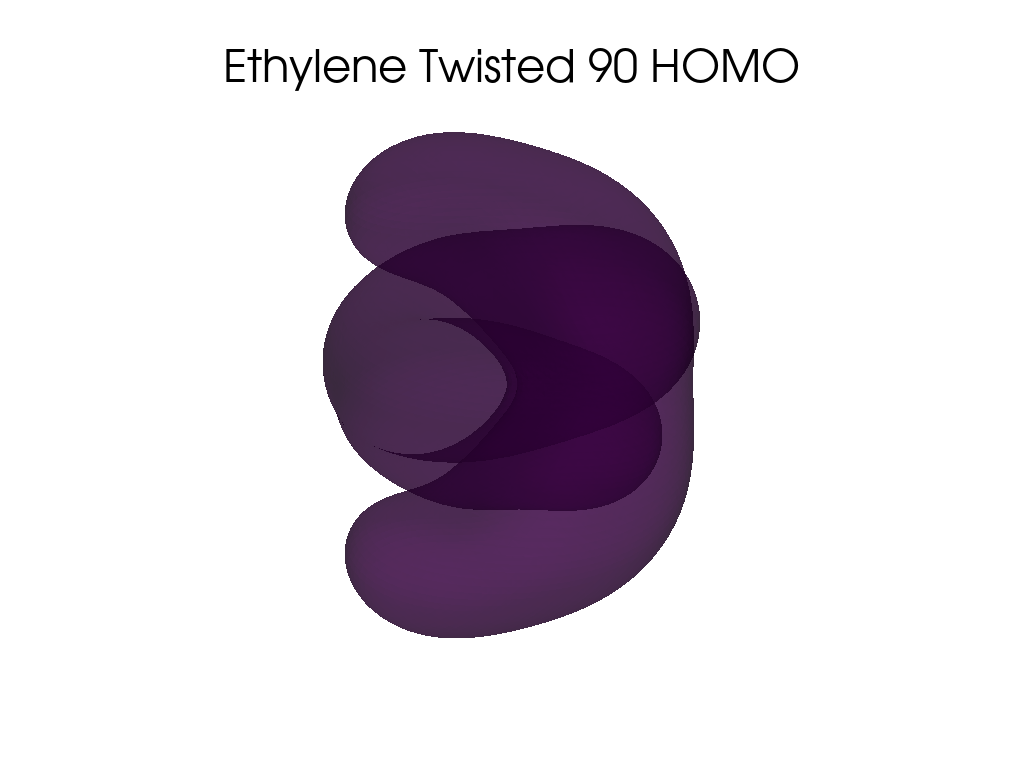

Saved: Ethylene_Twisted_90_HOMO.png


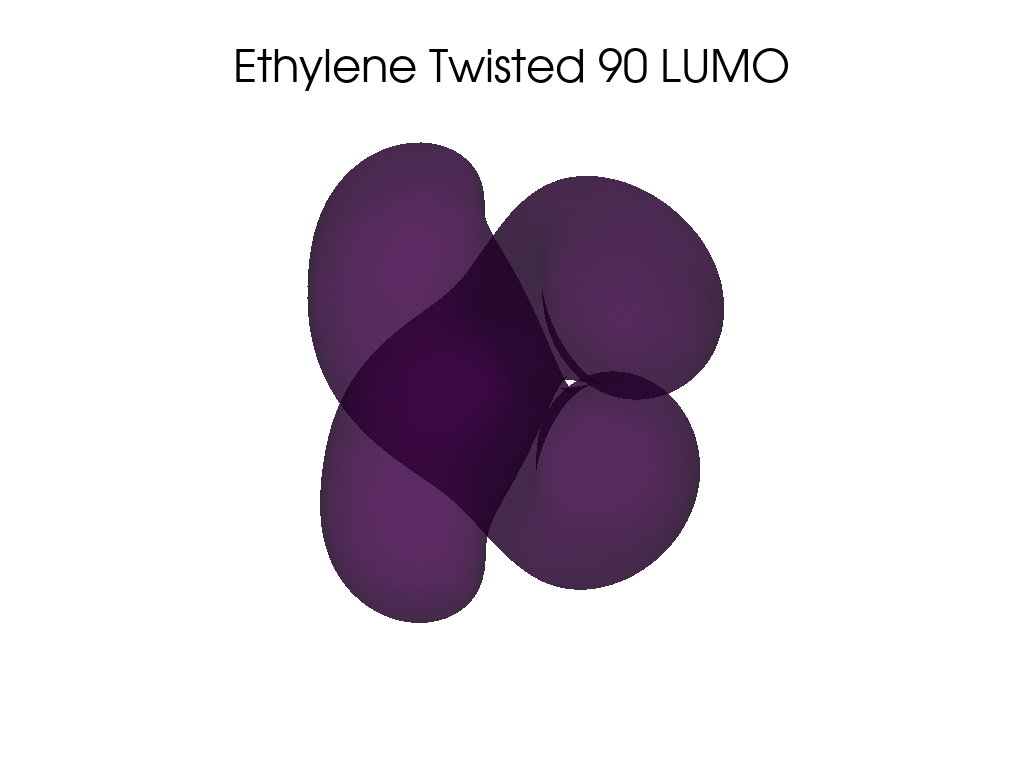

Saved: Ethylene_Twisted_90_LUMO.png

Done!
Check the two PNG files:
  Ethylene_Twisted_90_HOMO.png
  Ethylene_Twisted_90_LUMO.png


In [4]:
import pyvista as pv
import numpy as np


def plot_molecular_orbital(cube_file, title, iso_value=0.02):

    # Read cube file
    grid = pv.read(cube_file)

    # Get scalar field name
    scalar_name = grid.array_names[0]

    # Positive isosurface
    positive = grid.contour(
        isosurfaces=[iso_value],
        scalars=scalar_name
    )

    # Negative isosurface
    negative = grid.contour(
        isosurfaces=[-iso_value],
        scalars=scalar_name
    )

    # Plot
    plotter = pv.Plotter(off_screen=True)

    # Positive lobe
    plotter.add_mesh(
        positive,
        opacity=0.6,
        show_scalar_bar=False
    )

    # Negative lobe
    plotter.add_mesh(
        negative,
        opacity=0.6,
        show_scalar_bar=False
    )

    plotter.add_title(title)

    # Save image
    filename = title.replace(" ", "_") + ".png"

    plotter.show(
        screenshot=filename
    )

    plotter.close()

    print(f"Saved: {filename}")


# ============================================================
# HOMO
# ============================================================

plot_molecular_orbital(
    "ethylene_twisted_HOMO.cube",
    "Ethylene Twisted 90 HOMO"
)


# ============================================================
# LUMO
# ============================================================

plot_molecular_orbital(
    "ethylene_twisted_LUMO.cube",
    "Ethylene Twisted 90 LUMO"
)


print("\nDone!")
print("Check the two PNG files:")
print("  Ethylene_Twisted_90_HOMO.png")
print("  Ethylene_Twisted_90_LUMO.png")

In [5]:
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

active_space_transformer = ActiveSpaceTransformer(
    num_electrons=2,
    num_spatial_orbitals=2,
    active_orbitals=[7, 8]
)

active_problem = active_space_transformer.transform(problem)

print("Active-space spatial orbitals:",
      active_problem.num_spatial_orbitals)

print("Active-space particles:",
      active_problem.num_particles)

Active-space spatial orbitals: 2
Active-space particles: (1, 1)


In [6]:
fermionic_op = active_problem.hamiltonian.second_q_op()

print(fermionic_op)

Fermionic Operator
number spin orbitals=4, number terms=36
  -0.7092332585538299 * ( +_0 -_0 )
+ -0.5842594373240652 * ( +_1 -_1 )
+ -0.7092332585538299 * ( +_2 -_2 )
+ -0.5842594373240652 * ( +_3 -_3 )
+ 0.2959490046984019 * ( +_0 +_0 -_0 -_0 )
+ 0.1745087008382937 * ( +_0 +_1 -_1 -_0 )
+ 0.2959490046984019 * ( +_0 +_2 -_2 -_0 )
+ 0.1745087008382937 * ( +_0 +_3 -_3 -_0 )
+ 0.0007831728556851881 * ( +_0 +_0 -_1 -_1 )
+ 0.0007831728556851881 * ( +_0 +_1 -_0 -_1 )
+ 0.0007831728556851881 * ( +_0 +_2 -_3 -_1 )
+ 0.0007831728556851881 * ( +_0 +_3 -_2 -_1 )
+ 0.0007831728556851881 * ( +_1 +_0 -_1 -_0 )
+ 0.0007831728556851881 * ( +_1 +_1 -_0 -_0 )
+ 0.0007831728556851881 * ( +_1 +_2 -_3 -_0 )
+ 0.0007831728556851881 * ( +_1 +_3 -_2 -_0 )
+ 0.1745087008382937 * ( +_1 +_0 -_0 -_1 )
+ 0.2835332926807888 * ( +_1 +_1 -_1 -_1 )
+ 0.1745087008382937 * ( +_1 +_2 -_2 -_1 )
+ 0.2835332926807888 * ( +_1 +_3 -_3 -_1 )
+ 0.2959490046984019 * ( +_2 +_0 -_0 -_2 )
+ 0.1745087008382937 * ( +_2 +_1 -_1 -_2 )

In [7]:
from qiskit_nature.second_q.mappers import JordanWignerMapper

mapper = JordanWignerMapper()

qubit_hamiltonian = mapper.map(fermionic_op)

print(qubit_hamiltonian)

print(
    "Number of qubits:",
    qubit_hamiltonian.num_qubits
)

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-6.55517318e-01+0.j,  3.25250125e-02+0.j, -2.37540421e-02+0.j,
  3.25250125e-02+0.j, -2.37540421e-02+0.j,  8.68627640e-02+0.j,
  1.47974502e-01+0.j,  8.72543504e-02+0.j,  3.91586428e-04+0.j,
  3.91586428e-04+0.j,  3.91586428e-04+0.j,  3.91586428e-04+0.j,
  8.72543504e-02+0.j,  1.41766646e-01+0.j,  8.68627640e-02+0.j])
Number of qubits: 4


In [8]:
from qiskit_nature.second_q.circuit.library import HartreeFock

num_spatial_orbitals = active_problem.num_spatial_orbitals
num_particles = active_problem.num_particles

print("Active spatial orbitals:",
      num_spatial_orbitals)

print("Active particles:",
      num_particles)

initial_state = HartreeFock(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper
)

print(initial_state)

Active spatial orbitals: 2
Active particles: (1, 1)
     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
     ┌───┐
q_2: ┤ X ├
     └───┘
q_3: ─────
          


Number of ansatz parameters: 3


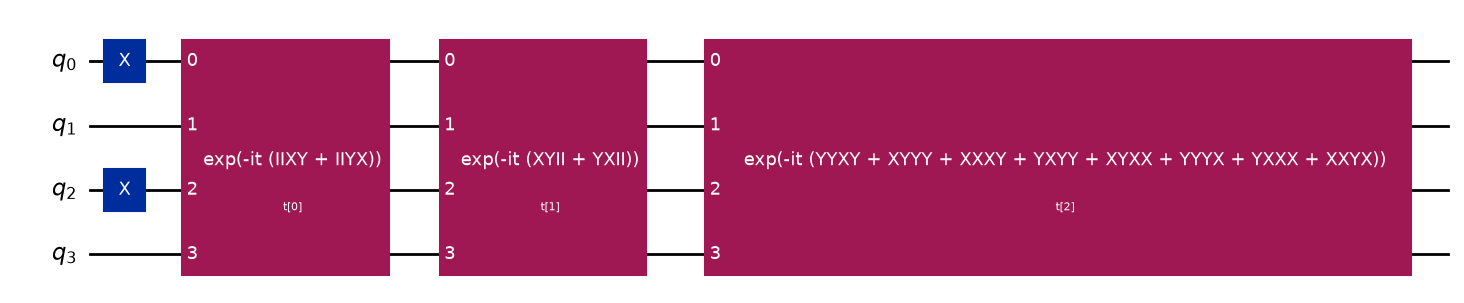

In [9]:
from qiskit_nature.second_q.circuit.library import UCC

ansatz = UCC(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper,
    excitations="sd",
    initial_state=initial_state
)

print(
    "Number of ansatz parameters:",
    ansatz.num_parameters
)

ansatz.decompose().draw("mpl")

In [10]:
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA

energy_history = []


def callback(eval_count, params, energy, metadata):
    energy_history.append(energy)


estimator = StatevectorEstimator()

optimizer = COBYLA(
    maxiter=1000
)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)

result = vqe.compute_minimum_eigenvalue(
    operator=qubit_hamiltonian
)

vqe_energy = result.eigenvalue.real

print("VQE Ground-State Energy:",
      vqe_energy)

/home/mohamed/vqe-env/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/mohamed/vqe-env/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


VQE Ground-State Energy: -0.9444752940859339


In [11]:
from qiskit_algorithms import NumPyMinimumEigensolver

exact_solver = NumPyMinimumEigensolver()

exact_result = exact_solver.compute_minimum_eigenvalue(
    qubit_hamiltonian
)

exact_energy = exact_result.eigenvalue.real

vqe_error = abs(
    vqe_energy - exact_energy
)

print("VQE Ground-State Energy:",
      vqe_energy)

print("Exact Active-Space Energy:",
      exact_energy)

print("VQE Error:",
      vqe_error)

VQE Ground-State Energy: -0.9444752940859339
Exact Active-Space Energy: -0.9460416399126792
VQE Error: 0.0015663458267453079


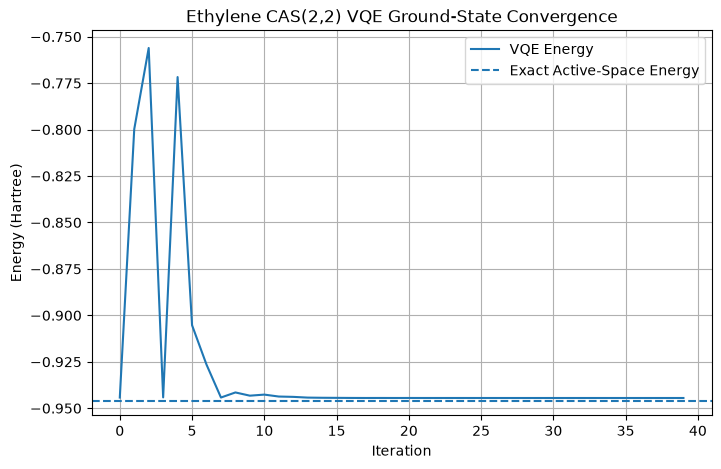

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    energy_history,
    label="VQE Energy"
)

plt.axhline(
    exact_energy,
    linestyle="--",
    label="Exact Active-Space Energy"
)

plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("Ethylene CAS(2,2) VQE Ground-State Convergence")

plt.legend()
plt.grid()

plt.show()

In [13]:
from qiskit.quantum_info import Statevector
import numpy as np

# ============================================================
# 1. VQE optimized ground-state candidate
# ============================================================

optimized_ansatz = ansatz.assign_parameters(
    result.optimal_parameters
)

phi0_state = Statevector.from_instruction(
    optimized_ansatz
)

phi0 = phi0_state.data

print("=" * 60)
print("QSE — VQE REFERENCE STATE")
print("=" * 60)

print("Number of qubits:", qubit_hamiltonian.num_qubits)
print("State dimension:", len(phi0))

print("Norm of phi0:",
      np.linalg.norm(phi0))

QSE — VQE REFERENCE STATE
Number of qubits: 4
State dimension: 16
Norm of phi0: 1.0000000000000002


In [14]:
from qiskit_nature.second_q.operators import FermionicOp

# ============================================================
# 2. Singlet π -> π* excitation
# ============================================================
#
# Active spatial orbitals:
#
# 0 -> π
# 1 -> π*
#
# Spin orbitals:
#
# 0 -> π  alpha
# 1 -> π  beta
# 2 -> π* alpha
# 3 -> π* beta
#
# Singlet-adapted excitation:
#
# a†(π* alpha) a(π alpha)
# +
# a†(π* beta)  a(π beta)
# ============================================================

excitation_op = FermionicOp(
    {
        "+_2 -_0": 1.0,
        "+_3 -_1": 1.0,
    },
    num_spin_orbitals=4
)

print("Fermionic excitation operator:")
print(excitation_op)

Fermionic excitation operator:
Fermionic Operator
number spin orbitals=4, number terms=2
  1.0 * ( +_2 -_0 )
+ 1.0 * ( +_3 -_1 )


In [15]:
# ============================================================
# 3. Jordan-Wigner mapping
# ============================================================

excitation_qubit_op = mapper.map(
    excitation_op
)

print("Qubit excitation operator:")
print(excitation_qubit_op)

Qubit excitation operator:
SparsePauliOp(['IXZY', 'IXZX', 'IYZY', 'IYZX', 'XZYI', 'XZXI', 'YZYI', 'YZXI'],
              coeffs=[0.  +0.25j, 0.25+0.j  , 0.25+0.j  , 0.  -0.25j, 0.  +0.25j, 0.25+0.j  ,
 0.25+0.j  , 0.  -0.25j])


In [16]:
# ============================================================
# 4. Generate excited-subspace vector
# ============================================================

phi1_state = phi0_state.evolve(
    excitation_qubit_op
)

phi1_raw = phi1_state.data

raw_norm = np.linalg.norm(phi1_raw)

print("=" * 60)
print("QSE EXCITED-SUBSPACE VECTOR")
print("=" * 60)

print("Raw norm =", raw_norm)
print("Raw norm² =", raw_norm**2)

QSE EXCITED-SUBSPACE VECTOR
Raw norm = 0.9999999995700883
Raw norm² = 0.9999999991401767


In [17]:
# ============================================================
# 5. Normalize phi1
# ============================================================

if raw_norm < 1e-12:
    raise ValueError(
        "Excitation produced an almost-zero vector."
    )

phi1 = phi1_raw / raw_norm

print("Normalized phi1 norm:",
      np.linalg.norm(phi1))

Normalized phi1 norm: 1.0


In [18]:
# ============================================================
# 6. Overlap matrix S
# ============================================================

S = np.array([
    [
        np.vdot(phi0, phi0),
        np.vdot(phi0, phi1)
    ],
    [
        np.vdot(phi1, phi0),
        np.vdot(phi1, phi1)
    ]
])

print("=" * 60)
print("QSE OVERLAP MATRIX S")
print("=" * 60)

print(S)

print("\nHermitian check:")
print(np.allclose(S, S.conj().T))

QSE OVERLAP MATRIX S
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Hermitian check:
True


In [19]:
# ============================================================
# 7. QSE Hamiltonian matrix
# ============================================================

H_matrix = qubit_hamiltonian.to_matrix()

H_qse = np.array([
    [
        np.vdot(phi0, H_matrix @ phi0),
        np.vdot(phi0, H_matrix @ phi1)
    ],
    [
        np.vdot(phi1, H_matrix @ phi0),
        np.vdot(phi1, H_matrix @ phi1)
    ]
])

print("=" * 60)
print("QSE HAMILTONIAN MATRIX H")
print("=" * 60)

print(H_qse)

print("\nHermitian check:")
print(np.allclose(H_qse, H_qse.conj().T))

QSE HAMILTONIAN MATRIX H
[[-0.94447529+0.j  0.        +0.j]
 [ 0.        +0.j -0.94604164+0.j]]

Hermitian check:
True


In [20]:
# ============================================================
# 8. Solve H c = E S c
# ============================================================

from scipy.linalg import eigh

qse_energies, qse_vectors = eigh(
    H_qse,
    S
)

qse_energies = np.real(qse_energies)

print("=" * 60)
print("QSE ENERGIES")
print("=" * 60)

for i, energy in enumerate(qse_energies):
    print(
        f"QSE Root {i}: "
        f"{energy:.10f} Ha"
    )

QSE ENERGIES
QSE Root 0: -0.9460416399 Ha
QSE Root 1: -0.9444752941 Ha


In [21]:
# ============================================================
# 9. QSE excitation energy
# ============================================================

HARTREE_TO_EV = 27.211386245988

qse_ground = qse_energies[0]
qse_excited = qse_energies[1]

qse_excitation_hartree = (
    qse_excited - qse_ground
)

qse_excitation_ev = (
    qse_excitation_hartree
    * HARTREE_TO_EV
)

print("=" * 60)
print("QSE EXCITATION ENERGY")
print("=" * 60)

print(f"QSE Ground State = "
      f"{qse_ground:.10f} Ha")

print(f"QSE Excited State = "
      f"{qse_excited:.10f} Ha")

print(f"\nExcitation = "
      f"{qse_excitation_hartree:.10f} Ha")

print(f"Excitation = "
      f"{qse_excitation_ev:.6f} eV")

QSE EXCITATION ENERGY
QSE Ground State = -0.9460416399 Ha
QSE Excited State = -0.9444752941 Ha

Excitation = 0.0015663458 Ha
Excitation = 0.042622 eV


In [22]:
print("-------------------------------------")

-------------------------------------


In [23]:
from pyscf import mcscf
import numpy as np

# ============================================================
# CASCI calculation: CAS(2,2)
# ============================================================

casci = mcscf.CASCI(
    mf,
    ncas=2,       # 2 active spatial orbitals: π and π*
    nelecas=2     # 2 active electrons
)

# Active orbitals:
# MO 7 -> π
# MO 8 -> π*
active_mo_indices = [7, 8]

mo_cas = casci.sort_mo(
    active_mo_indices,
    base=0
)

# Calculate 4 lowest CASCI roots
casci.fcisolver.nroots = 4

casci_result = casci.kernel(mo_cas)

# ============================================================
# CASCI Energies
# ============================================================

casci_energies = np.array(
    casci_result[0],
    ndmin=1
)

print("=" * 60)
print("CASCI ENERGIES — TWISTED ETHYLENE")
print("=" * 60)

for i, energy in enumerate(casci_energies):
    print(
        f"CASCI Root {i}: "
        f"{energy:.10f} Ha"
    )

# ============================================================
# Excitation Energy: Root 1 - Root 0
# ============================================================

HARTREE_TO_EV = 27.211386245988

casci_ground = casci_energies[0]
casci_excited = casci_energies[1]

casci_excitation_hartree = (
    casci_excited - casci_ground
)

casci_excitation_ev = (
    casci_excitation_hartree * HARTREE_TO_EV
)

print("\n" + "=" * 60)
print("CASCI EXCITATION ENERGY")
print("=" * 60)

print(f"Ground state : {casci_ground:.10f} Ha")
print(f"Root 1       : {casci_excited:.10f} Ha")

print(
    f"\nExcitation energy = "
    f"{casci_excitation_hartree:.10f} Ha"
)

print(
    f"Excitation energy = "
    f"{casci_excitation_ev:.6f} eV"
)


WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -76.9778125963491  E(CI) = -0.948388865215293  S^2 = 2.0000000
CASCI state   1  E = -76.9752074300654  E(CI) = -0.945783698931564  S^2 = 0.0000000
CASCI state   2  E = -76.7337966047894  E(CI) = -0.704372873655572  S^2 = 0.0000000
CASCI state   3  E = -76.7311884599202  E(CI) = -0.701764728786372  S^2 = 0.0000000
CASCI ENERGIES — TWISTED ETHYLENE
CASCI Root 0: -76.9778125963 Ha
CASCI Root 1: -76.9752074301 Ha
CASCI Root 2: -76.7337966048 Ha
CASCI Root 3: -76.7311884599 Ha

CASCI EXCITATION ENERGY
Ground state : -76.9778125963 Ha
Root 1       : -76.9752074301 Ha

Excitation energy = 0.0026051663 Ha
Excitation energy = 0.070890 eV


In [24]:
# ============================================================
# 10. QSE vs CASCI
# ============================================================

casci_excitation_hartree = (
    casci_energies[1] - casci_energies[0]
)

casci_excitation_ev = (
    casci_excitation_hartree
    * HARTREE_TO_EV
)

absolute_error = abs(
    qse_excitation_ev - casci_excitation_ev
)

relative_error = (
    absolute_error / abs(casci_excitation_ev)
) * 100

print("=" * 60)
print("QSE vs CASCI")
print("=" * 60)

print(f"QSE excitation   = "
      f"{qse_excitation_ev:.6f} eV")

print(f"CASCI excitation = "
      f"{casci_excitation_ev:.6f} eV")

print(f"\nAbsolute error = "
      f"{absolute_error:.6f} eV")

print(f"Relative error = "
      f"{relative_error:.2f}%")

QSE vs CASCI
QSE excitation   = 0.042622 eV
CASCI excitation = 0.070890 eV

Absolute error = 0.028268 eV
Relative error = 39.88%


he hardware-efficient ansatz 

In [25]:
from qiskit.circuit.library import EfficientSU2

num_qubits = qubit_hamiltonian.num_qubits

he_circuit = EfficientSU2(num_qubits=num_qubits, reps=3, entanglement="linear")
he_ansatz = initial_state.compose(he_circuit)

print("Number of qubits:", num_qubits)
print("HE ansatz parameters:", he_ansatz.num_parameters)
print("HE ansatz depth:", he_ansatz.decompose().depth())
print("UCCSD ansatz parameters:", ansatz.num_parameters)
print("UCCSD ansatz depth:", ansatz.decompose().decompose().depth())

Number of qubits: 4
HE ansatz parameters: 32
HE ansatz depth: 16
UCCSD ansatz parameters: 3
UCCSD ansatz depth: 83


/tmp/ipykernel_688378/3180130022.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  he_circuit = EfficientSU2(num_qubits=num_qubits, reps=3, entanglement="linear")


2. Ideal HE-VQE run (baseline, and gives a warm-start point for the noisy run):

In [26]:
from qiskit_algorithms.optimizers import SPSA
import numpy as np

he_energy_history = []
def he_callback(eval_count, params, energy, metadata):
    he_energy_history.append(energy)

he_vqe = VQE(
    estimator=estimator,          # the ideal StatevectorEstimator from cell 9
    ansatz=he_ansatz,
    optimizer=SPSA(maxiter=2000),
    initial_point=np.zeros(he_ansatz.num_parameters),
    callback=he_callback,
)
he_result = he_vqe.compute_minimum_eigenvalue(operator=qubit_hamiltonian)
he_vqe_energy = he_result.eigenvalue.real

print(f"HE VQE Energy:   {he_vqe_energy:.10f} Ha")
print(f"Exact Energy:    {exact_energy:.10f} Ha")
print(f"HE VQE Error:    {abs(he_vqe_energy - exact_energy):.10f} Ha")

HE VQE Energy:   -0.9453242817 Ha
Exact Energy:    -0.9460416399 Ha
HE VQE Error:    0.0007173582 Ha


3. Noise model + transpile (transpiling is required — this is exactly what caused the unknown instruction: EfficientSU2 error last time):

In [27]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error, ReadoutError
from qiskit import transpile

def build_noise_model(num_qubits, t1=50e3, t2=70e3, gate_time_1q=50, gate_time_2q=300,
                       p1=0.001, p2=0.01, readout_err=0.02):
    noise_model = NoiseModel()
    err_1q = thermal_relaxation_error(t1, t2, gate_time_1q).compose(depolarizing_error(p1, 1))
    noise_model.add_all_qubit_quantum_error(err_1q, ["sx", "x", "rz", "u1", "u2", "u3", "ry", "rx"])
    err_2q = thermal_relaxation_error(t1, t2, gate_time_2q).expand(
        thermal_relaxation_error(t1, t2, gate_time_2q)
    ).compose(depolarizing_error(p2, 2))
    noise_model.add_all_qubit_quantum_error(err_2q, ["cx", "cz", "ecr"])
    ro_error = ReadoutError([[1 - readout_err, readout_err], [readout_err, 1 - readout_err]])
    for q in range(num_qubits):
        noise_model.add_readout_error(ro_error, [q])
    return noise_model

noise_model = build_noise_model(num_qubits)
noisy_backend = AerSimulator(noise_model=noise_model)

he_ansatz_transpiled = transpile(he_ansatz, backend=noisy_backend, optimization_level=1)
print("Transpiled HE ansatz parameters:", he_ansatz_transpiled.num_parameters)

Transpiled HE ansatz parameters: 32


4. Noisy VQE run:

In [28]:
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

noisy_estimator = AerEstimator(
    options={
        "backend_options": {"noise_model": noise_model},
        "run_options": {"shots": 8192},
    }
)

noisy_energy_history = []
def noisy_callback(eval_count, params, energy, metadata):
    noisy_energy_history.append(energy)

noisy_vqe = VQE(
    estimator=noisy_estimator,
    ansatz=he_ansatz_transpiled,
    optimizer=SPSA(maxiter=150),
    initial_point=he_result.optimal_point,
    callback=noisy_callback,
)
noisy_result = noisy_vqe.compute_minimum_eigenvalue(operator=qubit_hamiltonian)
noisy_energy = noisy_result.eigenvalue.real

print(f"Noisy VQE Energy: {noisy_energy:.10f} Ha")
print(f"Exact Energy:     {exact_energy:.10f} Ha")
print(f"Noisy VQE Error:  {abs(noisy_energy - exact_energy):.10f} Ha")

Noisy VQE Energy: -0.7546390403 Ha
Exact Energy:     -0.9460416399 Ha
Noisy VQE Error:  0.1914025996 Ha


5. ZNE mitigation:

In [29]:
def fold_circuit(circuit, scale_factor):
    folded = circuit.copy()
    n_folds = int(round((scale_factor - 1) / 2))
    for _ in range(n_folds):
        folded = folded.compose(circuit.inverse()).compose(circuit)
    return folded

def zne_expectation(ansatz, params, hamiltonian, estimator, backend, scale_factors=(1, 3, 5)):
    bound = ansatz.assign_parameters(params)
    energies = []
    for s in scale_factors:
        folded = fold_circuit(bound, s)
        folded_transpiled = transpile(folded, backend=backend, optimization_level=1)
        job = estimator.run([(folded_transpiled, hamiltonian)])
        energies.append(job.result()[0].data.evs)
    coeffs = np.polyfit(scale_factors, energies, deg=1)
    return coeffs[-1], energies

zne_energy, raw_energies = zne_expectation(
    he_ansatz_transpiled, noisy_result.optimal_point, qubit_hamiltonian,
    noisy_estimator, noisy_backend
)

print("Raw noisy energies at scale factors (1,3,5):", raw_energies)
print(f"ZNE-extrapolated energy: {zne_energy:.10f} Ha")
print(f"ZNE error vs exact:      {abs(zne_energy - exact_energy):.10f} Ha")

Raw noisy energies at scale factors (1,3,5): [array(-0.75677885), array(-0.75677885), array(-0.75677885)]
ZNE-extrapolated energy: -0.7567788545 Ha
ZNE error vs exact:      0.1892627855 Ha
